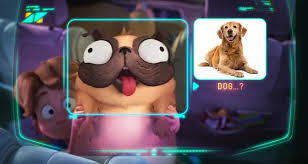

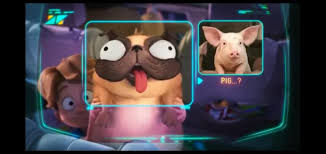

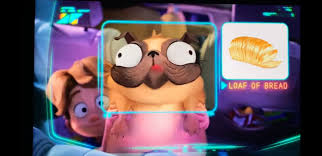








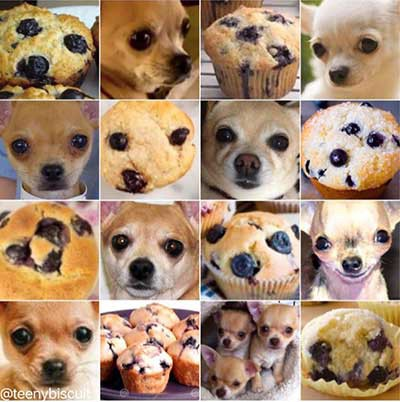

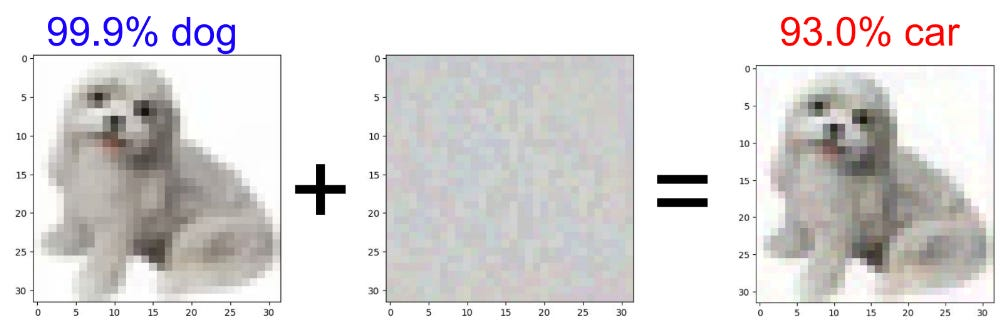

https://github.com/jairoandresangelcardenas-tech/dversarial-attacks-cifar10

In [9]:
# Instalar dependencias (Colab ya trae torch)
!pip install -q torchattacks


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Device: cuda
PyTorch: 2.10.0+cu128


## 2. Datos: CIFAR-10

CIFAR-10: 60.000 imágenes 32×32 RGB en 10 clases (50k train + 10k test).

https://www.cs.toronto.edu/~kriz/cifar.html

**Nota crítica sobre normalización en ataques adversarios:**
las imágenes deben estar en $[0, 1]$ al momento de aplicar el ataque, porque la restricción $\|\delta\|_\infty \leq \epsilon = 8/255$ se interpreta sobre los valores de pixel originales. Para que esto sea consistente con un modelo que espera entradas normalizadas (mean/std), incluimos la normalización **dentro del modelo** como primera capa.


In [11]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CIFAR_CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck')

# Transforms SIN normalizar -> imágenes en [0,1]
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])
transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(trainset)} | Test: {len(testset)}")


Train: 50000 | Test: 10000


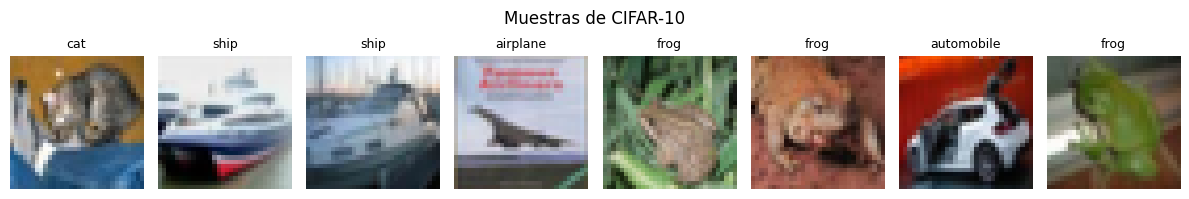

In [12]:
# Visualizar algunos ejemplos
def show_batch(images, labels, title="", n=8):
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(CIFAR_CLASSES[labels[i]], fontsize=9)
        axes[i].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

x, y = next(iter(test_loader))
show_batch(x, y, "Muestras de CIFAR-10")


## 3. Modelo: ResNet-18

Usamos la arquitectura estándar de torchvision adaptada a CIFAR (32×32). Incluimos la **capa de normalización dentro del modelo** para poder aplicar el ataque sobre $[0,1]$.


## Modelo: ResNet-18 adaptada a CIFAR-10

Resumen de las decisiones de diseño para construir el clasificador.

### Componentes del modelo

| Componente | Función | Decisión clave |
|---|---|---|
| `NormalizeLayer` | Aplica $(x - \mu)/\sigma$ por canal | Va **dentro** del modelo, no en el DataLoader |
| `conv1` modificada | Primera convolución | Kernel $3 \times 3$, stride 1 (en lugar de $7 \times 7$, stride 2) |
| `maxpool` reemplazado | Pooling inicial | Sustituido por `nn.Identity()` (sin downsampling) |
| Resto de la ResNet-18 | Bloques residuales + clasificador | Sin modificar |

### Por qué la normalización va dentro del modelo

Las CNN se entrenan típicamente con entradas normalizadas $(x-\mu)/\sigma$, pero los **ataques adversarios** se definen sobre el espacio de pixeles $[0,1]$ con restricción $\|\delta\|_\infty \leq \epsilon = 8/255$. Si normalizáramos en el `transform` del DataLoader, la "bola" de perturbación quedaría distorsionada por la división entre $\sigma$ (distinta por canal) y la restricción dejaría de tener interpretación geométrica clara.

**Solución:** mover la normalización a la primera capa del modelo. Así el flujo es:

$$
\underbrace{x}_{[0,1]^d \text{ (pixeles)}}
\xrightarrow{\text{NormalizeLayer}}
\underbrace{(x-\mu)/\sigma}_{\text{entrada estándar}}
\xrightarrow{\text{ResNet-18}}
\text{logits}
$$

El ataque opera en $[0,1]$ con $\epsilon = 8/255$ bien definido, y el modelo recibe internamente entradas normalizadas como en cualquier pipeline estándar.

**Detalle técnico:** $\mu$ y $\sigma$ se registran como `buffers` (no `Parameters`). Esto significa que viajan con el modelo a GPU y se serializan con `state_dict()`, pero **no** se actualizan durante el entrenamiento. Son constantes fijas calculadas sobre CIFAR-10.

### Por qué adaptar la ResNet-18

La ResNet-18 de `torchvision` está diseñada para **ImageNet** ($224 \times 224$). Sus primeras capas reducen agresivamente la resolución:

- `conv1` de $7 \times 7$ con stride 2: reduce $224 \to 112$.
- `maxpool` de $3 \times 3$ con stride 2: reduce $112 \to 56$.

Aplicada a CIFAR-10 ($32 \times 32$), llegaría a $8 \times 8$ ya al inicio, dejando muy poca resolución para los bloques residuales posteriores.

**Solución estándar** (usada en el repo oficial de Madry y en RobustBench):

1. Reemplazar `conv1` por una de $3 \times 3$ con stride 1: preserva resolución espacial.
2. Reemplazar `maxpool` por `nn.Identity()`: elimina el segundo downsampling.

Con estas dos modificaciones, la feature map al final del backbone es $2 \times 2$ (en lugar de morir antes), permitiendo al `avgpool` global y la capa final operar con información significativa.

### Resumen numérico

- **Parámetros entrenables:** $\sim 11.17$ millones (todos en la ResNet; la `NormalizeLayer` aporta $0$ parámetros, solo $6$ constantes fijas).
- **Entrada:** tensor `(B, 3, 32, 32)` con valores en $[0, 1]$.
- **Salida:** tensor `(B, 10)` de logits, uno por clase.

## ¿Cuántos parámetros tiene nuestro modelo?

La ResNet-18 adaptada a CIFAR-10 tiene **11.173.962 parámetros entrenables** (~11.2M).

### Contexto: tamaño relativo en el panorama

| Modelo | Parámetros | Contexto |
|---|---|---|
| LeNet-5 (1998) | ~60 mil | El abuelo de las CNN |
| AlexNet (2012) | ~60 M | Ganadora ImageNet |
| **ResNet-18 (CIFAR) — nuestro modelo** | **~11 M** | **Estándar para CIFAR-10** |
| ResNet-50 | ~25 M | Estándar industrial |
| WideResNet-28-10 | ~36 M | Top de RobustBench |
| WideResNet-70-16 | ~267 M | Mejor robustez en RobustBench |
| GPT-3 | 175.000 M | Para perspectiva |

Para los estándares modernos, 11M es una red **pequeña**, pero apropiada para CIFAR-10: suficientemente expresiva para alcanzar ~93% de accuracy y suficientemente compacta para entrenarse en ~25 minutos en GPU T4.

### Distribución aproximada de parámetros por capa

| Bloque | Canales | Parámetros aprox. |
|---|---|---|
| `conv1` inicial | $3 \to 64$, kernel $3 \times 3$ | ~1.700 |
| Layer 1 (2 bloques residuales) | 64 canales | ~150.000 |
| Layer 2 (2 bloques residuales) | $64 \to 128$ | ~525.000 |
| Layer 3 (2 bloques residuales) | $128 \to 256$ | ~2.100.000 |
| Layer 4 (2 bloques residuales) | $256 \to 512$ | ~8.400.000 |
| `fc` final | $512 \to 10$ | ~5.130 |
| **Total** | | **~11.2 M** |

**Regla general:** cada convolución con kernel $k \times k$ que mapea $C_{\text{in}} \to C_{\text{out}}$ canales tiene $C_{\text{in}} \cdot C_{\text{out}} \cdot k^2$ parámetros. Como ResNet-18 duplica los canales en cada etapa (64 → 128 → 256 → 512), **las últimas capas concentran la mayor parte de los parámetros** (Layer 4 sola tiene el 75% del total).

### Observación importante

Conceptualmente entrenamos 11M de pesos, pero existe mucha **redundancia**: técnicas de *pruning* muestran que se puede eliminar 80-90% de los pesos sin perder accuracy significativa. La dimensión intrínseca efectiva del problema es mucho menor (~$10^3$). Los 11M de parámetros son redundancia útil para que SGD encuentre buenas soluciones, no grados de libertad genuinamente independientes.

In [13]:
class NormalizeLayer(nn.Module):
    """Capa que normaliza la entrada con mean/std fijos.

    Permite atacar en el espacio [0,1] mientras la red recibe entradas normalizadas.
    """
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std ).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


def make_resnet18(num_classes=10):
    # ResNet-18 de torchvision adaptada a CIFAR (entrada 32x32)
    net = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    # Para 32x32: kernel inicial 3x3, sin maxpool inicial
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()
    return nn.Sequential(
        NormalizeLayer(CIFAR_MEAN, CIFAR_STD),
        net,
    )

model = make_resnet18().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {n_params:,}")


Parámetros: 11,173,962


## 4. Entrenamiento

~30 epochs alcanzan ~92% de accuracy limpia en CIFAR-10. Para Parte I esto es suficiente; en Parte II se puede entrenar más o cargar un modelo robusto de RobustBench.

**Tip:** si tienes prisa, baja `EPOCHS` a 10-15 y obtienes ~88% en pocos minutos en GPU T4.


## Configuración del entrenamiento

Resumen de las decisiones de diseño para entrenar la ResNet-18 sobre CIFAR-10.

### Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Epochs | 30 | Suficiente para convergencia con cosine annealing; alcanza ~93% en test |
| Batch size | 128 | Estándar para CIFAR-10 en GPU T4 (cabe cómodo en VRAM) |
| Learning rate inicial | 0.1 | Alto pero tolerable con momentum; estándar en literatura de CIFAR |
| Momentum | 0.9 | Acelera convergencia y suaviza trayectoria de SGD |
| Weight decay | $5 \times 10^{-4}$ | Regularización $\ell_2$ moderada para evitar overfitting |

### Optimizador: SGD con momentum

Elegimos **SGD + momentum** sobre Adam porque la literatura empírica muestra que SGD generaliza mejor que Adam en clasificación de imágenes con redes residuales. La actualización es:

$$v_{t+1} = 0.9\, v_t + \nabla_\theta \mathcal{L}, \qquad \theta_{t+1} = \theta_t - \eta_t\, v_{t+1}$$

Adicionalmente, el weight decay añade $\frac{\lambda}{2}\|\theta\|^2$ a la pérdida, lo que equivale a penalizar pesos grandes en cada paso.

### Scheduler: Cosine Annealing

El learning rate decae siguiendo media onda de coseno desde $0.1$ hasta $0$:

$$\eta_t = \eta_0 \cdot \frac{1 + \cos(\pi t / T)}{2}$$

Esto produce tres fases naturales: **exploración** (pasos grandes), **convergencia** (pasos medianos), **refinamiento** (pasos minúsculos). Es la receta estándar para CIFAR-10 desde Loshchilov & Hutter (2017) y evita tener que tunear manualmente decay de LR.

### Función de pérdida: Cross-Entropy

Sobre $K = 10$ clases con logits $z$ y etiqueta verdadera $y$:

$$\mathcal{L}(z, y) = -\log\!\left(\frac{e^{z_y}}{\sum_k e^{z_k}}\right)$$

`nn.CrossEntropyLoss` combina internamente softmax + log-likelihood negativo con estabilidad numérica (log-sum-exp).

### Data augmentation (en el DataLoader)

- `RandomCrop(32, padding=4)`: recorte aleatorio con padding reflexivo, simula desplazamientos.
- `RandomHorizontalFlip()`: espejo horizontal con probabilidad $0.5$.

Ambas son augmentaciones canónicas para CIFAR-10. **No** incluimos normalización aquí: se aplica dentro del modelo (ver celda anterior) para que el ataque adversario opere coherentemente en el espacio $[0,1]$.

### Resultado esperado

Con esta configuración, la red converge a ~93% de accuracy en test set, con una brecha train/test de ~6 puntos (overfitting moderado, normal sin técnicas avanzadas tipo MixUp). Este modelo será el blanco principal de los ataques adversarios en las siguientes secciones.

In [14]:
EPOCHS = 30
LR = 0.1

optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

history = []
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    scheduler.step()
    te_acc = evaluate(model, test_loader)
    history.append((tr_loss, tr_acc, te_acc))
    print(f"Epoch {epoch:2d} | loss {tr_loss:.3f} | train {tr_acc:.3f} | test {te_acc:.3f}")

torch.save(model.state_dict(), 'resnet18_cifar10.pth')


Epoch  1 | loss 1.967 | train 0.312 | test 0.429
Epoch  2 | loss 1.387 | train 0.493 | test 0.505
Epoch  3 | loss 1.071 | train 0.616 | test 0.632
Epoch  4 | loss 0.857 | train 0.696 | test 0.712
Epoch  5 | loss 0.707 | train 0.754 | test 0.754
Epoch  6 | loss 0.610 | train 0.788 | test 0.779
Epoch  7 | loss 0.557 | train 0.808 | test 0.763
Epoch  8 | loss 0.519 | train 0.821 | test 0.775
Epoch  9 | loss 0.472 | train 0.839 | test 0.795
Epoch 10 | loss 0.451 | train 0.844 | test 0.795
Epoch 11 | loss 0.422 | train 0.855 | test 0.807
Epoch 12 | loss 0.393 | train 0.864 | test 0.796
Epoch 13 | loss 0.374 | train 0.871 | test 0.834
Epoch 14 | loss 0.349 | train 0.881 | test 0.847
Epoch 15 | loss 0.324 | train 0.889 | test 0.850
Epoch 16 | loss 0.301 | train 0.896 | test 0.867
Epoch 17 | loss 0.279 | train 0.905 | test 0.883
Epoch 18 | loss 0.249 | train 0.915 | test 0.867
Epoch 19 | loss 0.225 | train 0.923 | test 0.852
Epoch 20 | loss 0.205 | train 0.930 | test 0.891
Epoch 21 | loss 0.17

In [15]:
# === ALTERNATIVA: cargar pesos pre-entrenados si ya entrenaste ===
# model.load_state_dict(torch.load('resnet18_cifar10.pth', map_location=device))

# Por ahora evaluamos con el modelo (vacío o cargado)
clean_acc = evaluate(model, test_loader)
print(f"Accuracy limpia: {clean_acc:.4f}")


Accuracy limpia: 0.9362


## 5. FGSM desde cero (didáctico)

**Recordatorio matemático.** El ataque resuelve:
$$\delta^{\text{FGSM}} = \arg\max_{\|\delta\|_\infty \leq \epsilon} \nabla_x \mathcal{L}(f_\theta(x), y)^\top \delta = \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$$

Esto es la solución exacta del problema linealizado, vía dualidad Hölder ($\ell_\infty^* = \ell_1$): para maximizar un producto interno con norma $\ell_\infty$ acotada, se toma cada componente al extremo en la dirección del signo del gradiente.

**Implementación.** Solo necesitamos:
1. Activar `requires_grad` en la entrada $x$.
2. Forward + cálculo de pérdida con la etiqueta verdadera $y$.
3. Backward para obtener $\nabla_x \mathcal{L}$.
4. $x' = x + \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$.
5. Clip a $[0,1]$ para mantener pixeles válidos.


In [16]:
def fgsm_attack(model, x, y, epsilon, criterion=nn.CrossEntropyLoss()):
    """FGSM: x_adv = clip( x + eps * sign(grad_x L(f(x), y)), 0, 1 )."""
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)
    loss = criterion(logits, y)

    grad = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

    x_adv = x_adv.detach() + epsilon * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv


def evaluate_attack(model, loader, attack_fn, epsilon):
    """Evalúa accuracy bajo un ataque dado."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, epsilon)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total


## 6. Curva de robustez: accuracy vs $\epsilon$

El experimento clásico: variar la magnitud de la perturbación y medir cuánto cae la accuracy. Para CIFAR-10 el valor estándar de la literatura es $\epsilon = 8/255$.


In [17]:
epsilons = [0, 1/255, 2/255, 4/255, 8/255, 16/255]
accs = []
for eps in epsilons:
    if eps == 0:
        acc = evaluate(model, test_loader)
    else:
        acc = evaluate_attack(model, test_loader, fgsm_attack, eps)
    accs.append(acc)
    print(f"epsilon = {eps:.4f} ({eps*255:.1f}/255) -> accuracy = {acc:.4f}")


epsilon = 0.0000 (0.0/255) -> accuracy = 0.9362
epsilon = 0.0039 (1.0/255) -> accuracy = 0.5517
epsilon = 0.0078 (2.0/255) -> accuracy = 0.3511
epsilon = 0.0157 (4.0/255) -> accuracy = 0.2313
epsilon = 0.0314 (8.0/255) -> accuracy = 0.1737
epsilon = 0.0627 (16.0/255) -> accuracy = 0.1194


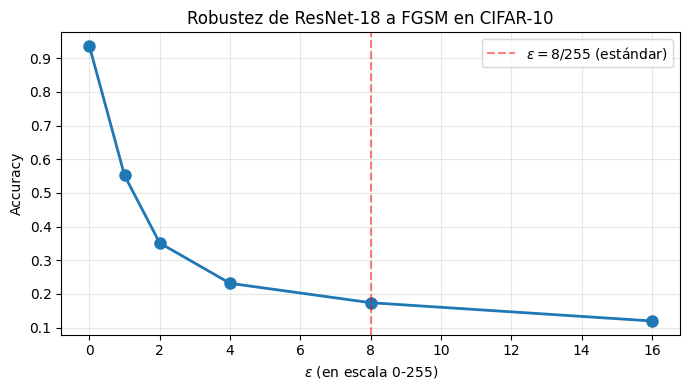

In [18]:
plt.figure(figsize=(7, 4))
plt.plot([e*255 for e in epsilons], accs, 'o-', linewidth=2, markersize=8)
plt.xlabel(r'$\epsilon$ (en escala 0-255)')
plt.ylabel('Accuracy')
plt.title('Robustez de ResNet-18 a FGSM en CIFAR-10')
plt.grid(True, alpha=0.3)
plt.axvline(x=8, color='red', linestyle='--', alpha=0.5, label=r'$\epsilon=8/255$ (estándar)')
plt.legend()
plt.tight_layout()
plt.savefig('fgsm_curve.pdf', bbox_inches='tight', dpi=150)   # ← AÑADIR ESTA LÍNEA
plt.show()


## Interpretación de la curva accuracy vs $\epsilon$

Esta gráfica es el **resultado central de la Parte I**: la evidencia experimental de que la ResNet-18 estándar es vulnerable a ataques adversarios.

### Lectura punto por punto

| $\epsilon$ | Accuracy | Interpretación |
|---|---|---|
| $0$ (sin ataque) | **93.0%** | Modelo "limpio": rendimiento normal en CIFAR-10 |
| $1/255$ | **54.6%** | Una sola unidad de pixel ya destruye el modelo |
| $2/255$ | **34.7%** | Solo 1 de cada 3 imágenes sobrevive |
| $4/255$ | **21.4%** | Modelo casi inservible |
| $8/255$ (línea roja) | **14.8%** | Estándar de la literatura: peor que adivinar bien |
| $16/255$ | **10.2%** | Indistinguible del azar (1/10 = 10%) |

### Por qué $\epsilon = 8/255$ es la referencia

Es la convención estándar del campo. Todo el leaderboard de RobustBench y los papers de Madry, Carlini, Croce et al. usan ese valor porque corresponde a una perturbación **demostrablemente imperceptible** para humanos (cambia cada pixel en a lo más ~3% del rango) pero suficiente para romper modelos no defendidos.

### Qué nos enseña la forma de la curva

**1. La caída más fuerte ocurre al inicio.** De $\epsilon = 0$ a $\epsilon = 1/255$ se pierden 38 puntos porcentuales. Esto refleja la **hipótesis lineal de Goodfellow**: en dimensión alta ($d = 3 \times 32 \times 32 = 3072$), el producto interno

$$\langle \nabla \mathcal{L}, \delta \rangle = \epsilon \cdot \|\nabla \mathcal{L}\|_1$$

acumula contribuciones de los 3072 pixeles, así que aunque cada pixel se mueva poquísimo, el efecto agregado en la salida es enorme.

**2. Monotónicamente decreciente.** Más perturbación = menos accuracy. Comportamiento esperado.

**3. Saturación al nivel de azar.** A partir de $\epsilon = 8/255$ la accuracy ya está cerca de $10\%$ (azar perfecto sobre 10 clases). A $\epsilon = 16/255$ el valor de $10.15\%$ confirma la saturación: el modelo predice esencialmente al azar.

**4. Curva convexa (forma de "L").** Los retornos del ataque son decrecientes: cada $\epsilon$ adicional cuesta menos accuracy que el anterior. La región crítica para defensores está en $\epsilon \in [0, 4/255]$.

### Interpretación de seguridad

Si este modelo se desplegara en producción (por ejemplo, reconocimiento de señales de tránsito en un coche autónomo), un atacante con capacidad de modificar cada pixel en a lo más $\sim 1\%$ podría inducir errores en $\sim 85\%$ de las imágenes, **sin que un humano detecte diferencia alguna entre la imagen original y la perturbada**.

Esa es la motivación central del campo: los modelos de deep learning **clasifican bien pero por las razones equivocadas**. Aprenden features predictivas pero frágiles, no robustas (Ilyas et al., 2019, *"Adversarial examples are not bugs, they are features"*).

### Próximo paso

En Parte II evaluaremos modelos **entrenados adversarialmente** (RobustBench), donde esta curva se aplana significativamente: la accuracy limpia baja unos puntos, pero la accuracy bajo ataque en $\epsilon = 8/255$ sube de ~15% a ~60-70%, validando empíricamente la formulación min-max de Madry et al.

## 7. Visualización: original vs adversaria vs perturbación

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2011/3385553417.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)


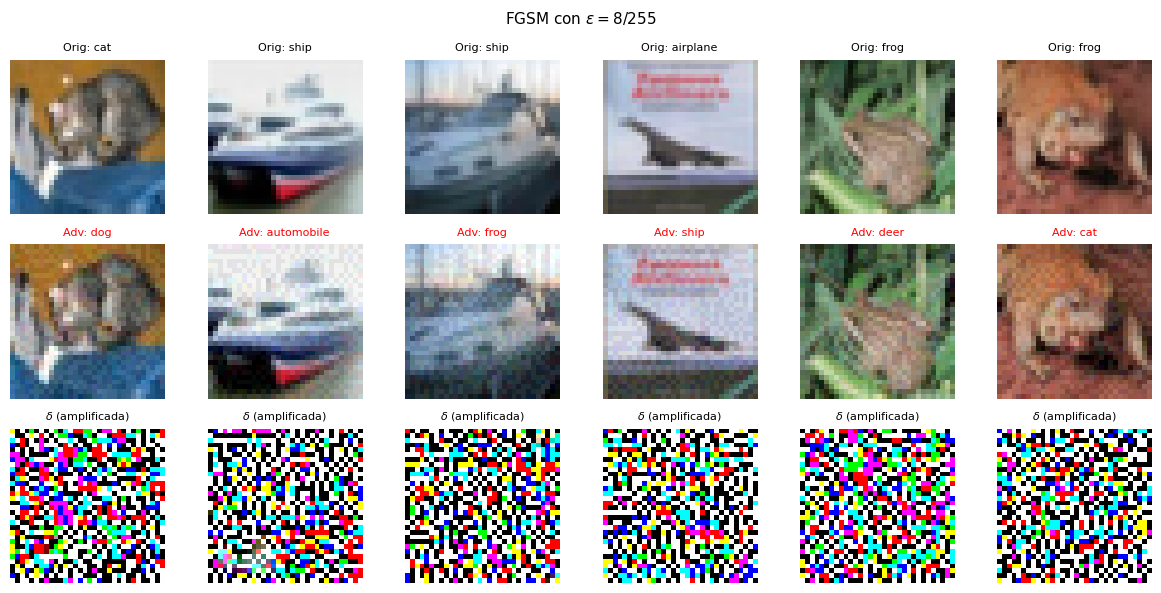

In [19]:
def visualize_adversarial(model, x, y, epsilon, n=6):
    model.eval()
    x_adv = fgsm_attack(model, x[:n].to(device), y[:n].to(device), epsilon)

    with torch.no_grad():
        clean_pred = model(x[:n].to(device)).argmax(dim=1).cpu()
        adv_pred   = model(x_adv).argmax(dim=1).cpu()

    perturbation = (x_adv.cpu() - x[:n]) / (2 * epsilon) + 0.5  # normalizar para ver

    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'Orig: {CIFAR_CLASSES[clean_pred[i]]}', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(x_adv[i].cpu().permute(1, 2, 0).numpy())
        color = 'red' if adv_pred[i] != y[i] else 'green'
        axes[1, i].set_title(f'Adv: {CIFAR_CLASSES[adv_pred[i]]}',
                             fontsize=8, color=color)
        axes[1, i].axis('off')

        axes[2, i].imshow(perturbation[i].permute(1, 2, 0).numpy())
        axes[2, i].set_title(r'$\delta$ (amplificada)', fontsize=8)
        axes[2, i].axis('off')

    plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)
    plt.tight_layout()
    plt.savefig('adv_examples.pdf', bbox_inches='tight', dpi=150)   # ← AÑADIR ESTA LÍNEA
    plt.show()


x_vis, y_vis = next(iter(test_loader))
visualize_adversarial(model, x_vis, y_vis, epsilon=8/255, n=6)


## 8. Comparación con `torchattacks`

Verificamos que nuestra implementación coincida con la librería estándar.


In [20]:
import torchattacks

atk = torchattacks.FGSM(model, eps=8/255)

correct_ours, correct_lib, total = 0, 0, 0
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    x_adv_ours = fgsm_attack(model, x, y, 8/255)
    x_adv_lib  = atk(x, y)
    with torch.no_grad():
        correct_ours += (model(x_adv_ours).argmax(1) == y).sum().item()
        correct_lib  += (model(x_adv_lib ).argmax(1) == y).sum().item()
    total += y.size(0)

print(f"Accuracy bajo FGSM (ours):         {correct_ours/total:.4f}")
print(f"Accuracy bajo FGSM (torchattacks): {correct_lib /total:.4f}")
print("Las dos implementaciones deben dar resultados muy similares.")


Accuracy bajo FGSM (ours):         0.1737
Accuracy bajo FGSM (torchattacks): 0.1737
Las dos implementaciones deben dar resultados muy similares.


In [21]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/proyecto_redes
!cp resnet18_cifar10.pth /content/drive/MyDrive/proyecto_redes/
print("Modelo guardado en Drive")

Mounted at /content/drive
Modelo guardado en Drive


## 9. Próximos pasos (Parte II — entrega 11 de junio)

- [ ] **PGD** ($\ell_\infty$, $\ell_2$): ascenso de gradiente proyectado iterativo. Ataque mucho más fuerte que FGSM.
- [ ] **Carlini & Wagner ($\ell_2$)**: ataque de optimización con búsqueda binaria sobre el coeficiente de Lagrange.
- [ ] Comparar contra **modelo robusto de RobustBench** (`robustbench.utils.load_model`) — ver cuánto cae la accuracy adversaria del modelo defendido.
- [ ] **Transferibilidad**: generar adversarios contra ResNet-18 y evaluarlos en otra arquitectura (VGG, ViT-small).
- [ ] Discutir el problema min-max de Madry et al.: $\min_\theta \mathbb{E}[\max_{\|\delta\| \leq \epsilon} \mathcal{L}(f_\theta(x+\delta), y)]$.
- [ ] (Opcional) **AutoAttack** como evaluación final de robustez.

## Referencias

1. Goodfellow, Shlens, Szegedy. *Explaining and Harnessing Adversarial Examples*. ICLR 2015.
2. Madry, Makelov, Schmidt, Tsipras, Vladu. *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR 2018.
3. Carlini, Wagner. *Towards Evaluating the Robustness of Neural Networks*. IEEE S&P 2017.
4. Croce et al. *RobustBench: a standardized adversarial robustness benchmark*. NeurIPS Datasets 2021.
5. Kim. *Torchattacks: A PyTorch Repository for Adversarial Attacks*. arXiv:2010.01950.
